# Phase 2 — final runs across maps

Phase 2 carries the hyperparameters validated on Cologne-v1 over to the other
maps, so the question here is no longer "do these hyperparameters reproduce?"
but "how does each algorithm do on each map?".

Every run is scored the same way as the paper figure: the best eval of the run,
expressed relative to that map's prioritized heuristic —
`(return - H_PS) / |H_PS|`. 0% is the heuristic, positive is better than it.
That normalization is what lets maps whose returns differ by two orders of
magnitude share one axis.

Constrained (default-budget) runs only. Phase 3 adds the unconstrained setting;
see `EXTRA_FINAL_FILTERS` below for where that split will go.

Maps with no runs yet render as empty panels, so this notebook is safe to re-run
as phase 2 fills in. Only *finished* runs are served from cache — anything still
training is re-downloaded on every execution.

In [ ]:
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import wandb
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter, MaxNLocator
from tqdm.auto import tqdm
from utils.run_data_handling import Run
from utils.wandb_utils import download_run, store_run_data

api = wandb.Api()

In [38]:
ENTITY = "imp-act"
METRIC = "test_returned_episode_returns"

# The training scripts name the project f"{PROJECT}_{map_name}", so each map has
# its own project under this prefix; they are discovered rather than hardcoded.
FINAL_RUNS_PROJECT_PREFIX = "imp-act-jaxMARL-final-runs"
FINAL_RUNS_CACHE = Path("data/final_runs")

# Extra W&B filters on the final runs. Phase 3 adds unconstrained runs to these
# same projects — narrow the selection here once they exist so they do not get
# pooled with the constrained seeds.
EXTRA_FINAL_FILTERS = {}

# Maps in figure order, with the panel title and the prioritized heuristic the
# returns are normalized against.
#
# H_PS values are the prioritized segment-based heuristic (the H_PS annotated on
# the paper figure). Note evaluation/plotting/figure_3.ipynb normalizes against a
# different, older baseline (-274.0M / -8.19B / -33.1B) — these numbers are not
# interchangeable, and every percentage below moves if they are swapped.
MAPS = {
    "ToyExample-v2": {
        "title": "ToyExample\n(12 agents)",
        "heuristic": -472.2e6,
    },
    "Cologne-v1": {
        "title": "Cologne\n(60 agents)",
        "heuristic": -12.6e9,
    },
    "CologneBonnDusseldorf-v1": {
        "title": "CologneBonnDusseldorf\n(178 agents)",
        "heuristic": -43.7e9,
    },
}

# x-axis order and display names, matching evaluation/plotting/figure_3.ipynb.
ALG_ORDER = ["vdn_rnn", "qmix_rnn", "pqn_rnn", "mappo_rnn", "ippo_rnn"]
ALG_NAMES = {
    "vdn_rnn": "VDN",
    "qmix_rnn": "QMIX",
    "pqn_rnn": "PQN-VDN",
    "mappo_rnn": "MAPPO",
    "ippo_rnn": "IPPO",
}

# Runs below this fraction of training stay in the coverage table and the
# learning curves but are dropped from the box plot, where a half-trained seed
# would read as a bad result rather than an unfinished one.
MIN_COMPLETED_FRAC = 1.0

# Floor of the relative-performance axis, as in the paper figure. A diverged
# seed can sit below -100%, which would flatten every other box; seeds below the
# floor are drawn *at* it so none disappear, and the bottom tick reads "≤".
# The summary table always reports true values.
Y_FLOOR = -40

MAX_WORKERS = 8

## Pull + cache runs

One row per run, keyed by map and algorithm, plus the `Run` objects for the
learning curves. A run is served from disk only if its **cached** state is
`finished`, so a seed that was still training when it was last downloaded is
fetched again instead of being frozen mid-curve.

In [39]:
def eval_points(run):
    """The run's evaluations as an (env_step, METRIC) frame.

    The metric is logged only on eval updates, so every other history row is NaN
    for it; both columns are dropped together to keep steps and returns aligned.
    """
    empty = pd.DataFrame(columns=["env_step", METRIC], dtype=float)
    if run is None or run.history is None or METRIC not in run.history:
        return empty
    return run.history[["env_step", METRIC]].dropna().reset_index(drop=True)


def completed_frac(run, config):
    """Fraction of training reached, from the last logged env_step.

    Every training script runs exactly
    NUM_UPDATES = TOTAL_TIMESTEPS // NUM_STEPS // NUM_ENVS updates and logs
    env_step every update, so a complete run ends at exactly
    NUM_UPDATES * NUM_ENVS * NUM_STEPS.
    """
    num_updates = config["TOTAL_TIMESTEPS"] // config["NUM_STEPS"] // config["NUM_ENVS"]
    expected_final_step = num_updates * config["NUM_ENVS"] * config["NUM_STEPS"]
    env_steps = None if run is None else run.get_history_values("env_step")
    if env_steps is None or env_steps.dropna().empty:
        return 0.0
    return float(env_steps.dropna().max()) / expected_final_step


def relative_to_heuristic(values, map_name):
    """Percent better than the map's heuristic; 0 = heuristic, positive = better."""
    heuristic = MAPS[map_name]["heuristic"]
    return (values - heuristic) / abs(heuristic) * 100


def _load_one_run(project, remote_run, cache_dir):
    run_path = cache_dir / project / remote_run.id
    cached = None
    if (run_path / "config.yaml").exists() and (run_path / "summary.yaml").exists():
        try:
            cached = Run(run_path)
        except Exception:
            cached = None

    # Only a finished run is immutable and safe to reuse from disk.
    if cached is None or cached.state != "finished":
        store_run_data(download_run(remote_run), run_path)
        try:
            cached = Run(run_path)
        except Exception:
            cached = None  # e.g. a run that has not logged anything yet

    config = dict(remote_run.config)
    map_name = (config.get("ENV_KWARGS") or {}).get("map_name")
    returns = eval_points(cached)[METRIC]
    best = returns.max() if len(returns) else np.nan
    row = {
        "map_name": map_name,
        "project": project,
        "run_id": remote_run.id,
        "name": remote_run.name,
        "alg": config.get("ALG_NAME"),
        "seed": config.get("SEED"),
        "state": remote_run.state,
        "n_evals": len(returns),
        "completed_frac": completed_frac(cached, config),
        "best": best,
        "best_rel": relative_to_heuristic(best, map_name)
        if map_name in MAPS
        else np.nan,
    }
    return (project, remote_run.id), cached, row


def load_runs(targets, cache_dir):
    """targets: list of (project, remote run) pairs."""
    rows, runs = [], {}
    with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = [
            executor.submit(_load_one_run, project, remote_run, cache_dir)
            for project, remote_run in targets
        ]
        for future in tqdm(as_completed(futures), total=len(futures), desc="Loading runs"):
            key, run, row = future.result()
            runs[key] = run
            rows.append(row)
    return pd.DataFrame(rows), runs

In [40]:
final_projects = sorted(
    p.name for p in api.projects(ENTITY) if p.name.startswith(FINAL_RUNS_PROJECT_PREFIX)
)
targets = [
    (project, remote_run)
    for project in final_projects
    for remote_run in api.runs(
        f"{ENTITY}/{project}",
        filters={
            "config.ENV_KWARGS.map_name": {"$in": list(MAPS)},
            **EXTRA_FINAL_FILTERS,
        },
        per_page=500,
    )
]

print(f"projects: {final_projects}")
print(f"{len(targets)} run(s) across {len(MAPS)} map(s)")

runs_df, loaded_runs = load_runs(targets, FINAL_RUNS_CACHE)

if runs_df.empty:
    runs_df = pd.DataFrame(
        columns=[
            "map_name", "project", "run_id", "name", "alg", "seed", "state",
            "n_evals", "completed_frac", "best", "best_rel",
        ]
    )
else:
    runs_df["map_name"] = pd.Categorical(
        runs_df["map_name"], categories=list(MAPS), ordered=True
    )
    runs_df["alg"] = pd.Categorical(runs_df["alg"], categories=ALG_ORDER, ordered=True)
    runs_df = runs_df.sort_values(["map_name", "alg", "seed"]).reset_index(drop=True)

runs_df

projects: ['imp-act-jaxMARL-final-runs_Cologne-v1', 'imp-act-jaxMARL-final-runs_CologneBonnDusseldorf-v1']
28 run(s) across 3 map(s)


Loading runs: 100%|██████████| 28/28 [00:02<00:00, 13.36it/s]


,map_name,project,run_id,name,alg,seed,state,n_evals,completed_frac,best,best_rel
0,Cologne-v1,imp-act-jaxMARL-final-runs_Cologne-v1,jgg1wols,pqn_rnn_road_env_Cologne-v1_200,pqn_rnn,200,finished,7660,1.0,-1.164312e+10,7.594248
1,Cologne-v1,imp-act-jaxMARL-final-runs_Cologne-v1,sf9mo3mz,pqn_rnn_road_env_Cologne-v1_201,pqn_rnn,201,finished,7660,1.0,-1.123083e+10,10.866408
2,Cologne-v1,imp-act-jaxMARL-final-runs_Cologne-v1,x8zpvfsr,pqn_rnn_road_env_Cologne-v1_202,pqn_rnn,202,finished,7660,1.0,-1.221787e+10,3.032743
3,Cologne-v1,imp-act-jaxMARL-final-runs_Cologne-v1,o4r1d1kq,pqn_rnn_road_env_Cologne-v1_203,pqn_rnn,203,finished,7660,1.0,-1.683415e+10,-33.604385
4,Cologne-v1,imp-act-jaxMARL-final-runs_Cologne-v1,mmgfmvwh,pqn_rnn_road_env_Cologne-v1_204,pqn_rnn,204,finished,7660,1.0,-1.140764e+10,9.463170
5,Cologne-v1,imp-act-jaxMARL-final-runs_Cologne-v1,gpg8i24b,pqn_rnn_road_env_Cologne-v1_205,pqn_rnn,205,finished,7660,1.0,-1.168004e+10,7.301238
6,Cologne-v1,imp-act-jaxMARL-final-runs_Cologne-v1,67jn2rw8,pqn_rnn_road_env_Cologne-v1_206,pqn_rnn,206,finished,7660,1.0,-2.081320e+10,-65.184089
7,Cologne-v1,imp-act-jaxMARL-final-runs_Cologne-v1,6l9vtwve,pqn_rnn_road_env_Cologne-v1_207,pqn_rnn,207,finished,7660,1.0,-1.284663e+10,-1.957356
8,Cologne-v1,imp-act-jaxMARL-final-runs_Cologne-v1,r4zhzgdy,pqn_rnn_road_env_Cologne-v1_208,pqn_rnn,208,finished,7660,1.0,-1.162093e+10,7.770376
9,Cologne-v1,imp-act-jaxMARL-final-runs_Cologne-v1,e17ky08s,pqn_rnn_road_env_Cologne-v1_209,pqn_rnn,209,finished,7660,1.0,-2.706536e+10,-114.804480


## Coverage

Complete seeds per algorithm and map — the cells that feed the box plot. A count
in brackets is seeds still training, which appear in the learning curves only.

In [41]:
def coverage_cell(alg, map_name):
    cell = runs_df[(runs_df["alg"] == alg) & (runs_df["map_name"] == map_name)]
    complete = int((cell["completed_frac"] >= MIN_COMPLETED_FRAC).sum())
    training = len(cell) - complete
    return f"{complete}" + (f" (+{training})" if training else "")


coverage_df = pd.DataFrame(
    {
        map_name: {ALG_NAMES[alg]: coverage_cell(alg, map_name) for alg in ALG_ORDER}
        for map_name in MAPS
    }
)
display(coverage_df.style.set_caption("complete seeds (+ still training)"))

missing = [
    f"{ALG_NAMES[alg]} on {map_name}"
    for map_name in MAPS
    for alg in ALG_ORDER
    if runs_df[(runs_df["alg"] == alg) & (runs_df["map_name"] == map_name)].empty
]
if missing:
    print(f"No runs yet ({len(missing)}): " + ", ".join(missing))
else:
    print("Every algorithm has runs on every map.")

,ToyExample-v2,Cologne-v1,CologneBonnDusseldorf-v1
VDN,0,0,3
QMIX,0,0,2
PQN-VDN,0,10,0
MAPPO,0,3,0
IPPO,0,10,0


No runs yet (10): VDN on ToyExample-v2, QMIX on ToyExample-v2, PQN-VDN on ToyExample-v2, MAPPO on ToyExample-v2, IPPO on ToyExample-v2, VDN on Cologne-v1, QMIX on Cologne-v1, PQN-VDN on CologneBonnDusseldorf-v1, MAPPO on CologneBonnDusseldorf-v1, IPPO on CologneBonnDusseldorf-v1


## Are the same hyperparameters being used everywhere?

Phase 2 is meant to carry the Cologne-v1 hyperparameters over unchanged, so per
algorithm this diffs each map's config against the Cologne-v1 config and reports
what differs. Map-specific and bookkeeping keys are ignored; anything else that
shows up is either an intentional per-map change or a mistake, and either way it
means that algorithm's maps are not directly comparable.

In [42]:
REFERENCE_MAP = "Cologne-v1"

# Keys expected to differ between two maps' runs.
EXPECTED_DIFFS = {
    "ENV_KWARGS",  # holds map_name
    "SEED",
    "NUM_SEEDS",
    "HYDRA_PATH",
    "SAVE_PATH",
    "WANDB_DIR",
    "WANDB_MODE",
    "WANDB_RUN_ID",
    "WANDB_RUN_NAME",
    "WANDB_RUN_URL",
    "ENTITY",
    "PROJECT",
    "HYP_TUNE",
    "COMBO_ID",
    "RUN_LABEL",
}


def config_of(row):
    run = loaded_runs.get((row["project"], row["run_id"]))
    return {} if run is None else dict(run.config)


diff_rows = []
for alg in ALG_ORDER:
    alg_runs = runs_df[runs_df["alg"] == alg]
    reference_runs = alg_runs[alg_runs["map_name"] == REFERENCE_MAP]
    if reference_runs.empty:
        continue
    reference = config_of(reference_runs.iloc[0])

    for map_name in MAPS:
        if map_name == REFERENCE_MAP:
            continue
        map_runs = alg_runs[alg_runs["map_name"] == map_name]
        if map_runs.empty:
            continue
        other = config_of(map_runs.iloc[0])
        keys = (set(reference) | set(other)) - EXPECTED_DIFFS
        for key in sorted(keys):
            if reference.get(key, "<absent>") != other.get(key, "<absent>"):
                diff_rows.append(
                    {
                        "alg": ALG_NAMES[alg],
                        "key": key,
                        REFERENCE_MAP: reference.get(key, "<absent>"),
                        map_name: other.get(key, "<absent>"),
                    }
                )

if diff_rows:
    print(f"Config differences vs {REFERENCE_MAP}:")
    display(pd.DataFrame(diff_rows))
else:
    print(f"No hyperparameter differences vs {REFERENCE_MAP} among the maps loaded.")

No hyperparameter differences vs Cologne-v1 among the maps loaded.


## Performance relative to the heuristic

One panel per map, one box per algorithm, every seed drawn on top. The red line
is that map's prioritized heuristic (0%), and `H_PS` in each panel gives the
absolute return it corresponds to. Seed counts are under each algorithm label.

The axis stops at `Y_FLOOR`: a diverged seed can sit below -100%, which would
squash every other box flat. Such seeds are drawn on the floor and called out in
the panel, so a run that never learned is visible rather than silently off-plot —
the summary table below reports their true values.

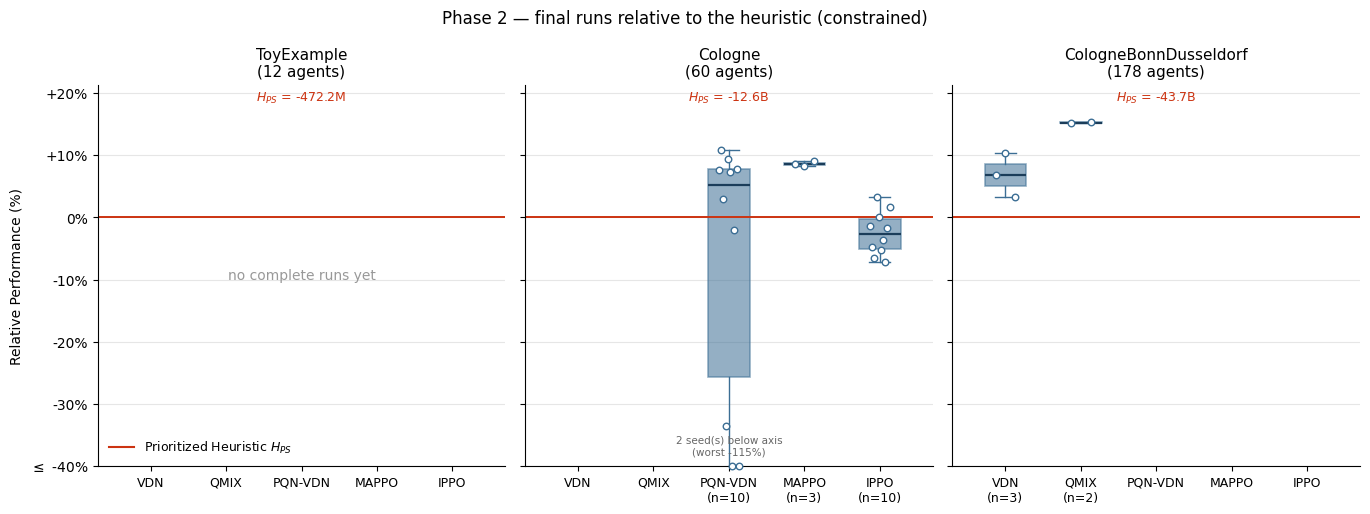

In [43]:
BOX_COLOR = "#3c6e94"
HEURISTIC_COLOR = "#cc3311"


def _percent_tick(value, _):
    if value == 0:
        return "0%"
    if value <= Y_FLOOR:
        return f"$\leq$ {Y_FLOOR:+,.0f}%"
    return f"{value:+,.0f}%"


percent_formatter = FuncFormatter(_percent_tick)


def format_return(value):
    """Absolute return in the magnitude that reads best for the map."""
    if abs(value) >= 1e9:
        return f"{value / 1e9:,.1f}B"
    return f"{value / 1e6:,.1f}M"


box_df = runs_df[runs_df["completed_frac"] >= MIN_COMPLETED_FRAC]
excluded = runs_df[runs_df["completed_frac"] < MIN_COMPLETED_FRAC]
if not excluded.empty:
    detail = ", ".join(
        f"{ALG_NAMES[alg]}/{map_name} {len(cell)} run(s) at "
        f"{cell['completed_frac'].min():.0%}–{cell['completed_frac'].max():.0%}"
        for (map_name, alg), cell in excluded.groupby(
            ["map_name", "alg"], observed=True
        )
    )
    print(
        f"Box plot excludes {len(excluded)} run(s) under {MIN_COMPLETED_FRAC:.0%} "
        f"of training: {detail}"
    )

fig, axes = plt.subplots(
    1, len(MAPS), figsize=(4.6 * len(MAPS), 5.2), sharey=True, squeeze=False
)

for ax, (map_name, map_info) in zip(axes[0], MAPS.items()):
    tick_labels = []
    for index, alg in enumerate(ALG_ORDER):
        values = box_df[
            (box_df["alg"] == alg) & (box_df["map_name"] == map_name)
        ]["best_rel"].dropna()
        tick_labels.append(
            f"{ALG_NAMES[alg]}\n(n={len(values)})" if len(values) else ALG_NAMES[alg]
        )
        if values.empty:
            continue

        box = ax.boxplot(
            [values.to_numpy()],
            positions=[index],
            widths=0.55,
            patch_artist=True,
            medianprops={"color": "#1b3d5a", "linewidth": 1.6},
            whiskerprops={"color": BOX_COLOR, "linewidth": 1.0},
            capprops={"color": BOX_COLOR, "linewidth": 1.0},
            showfliers=False,
        )
        for patch in box["boxes"]:
            patch.set(facecolor=BOX_COLOR, edgecolor=BOX_COLOR, alpha=0.55, linewidth=1.2)

        # Every seed on top of its box, spread deterministically. Seeds below
        # the floor are drawn at it so a diverged run stays visible.
        spread = np.linspace(-0.13, 0.13, len(values)) if len(values) > 1 else [0.0]
        below_floor = values < Y_FLOOR
        ax.scatter(
            index + np.asarray(spread),
            np.clip(values.to_numpy(), Y_FLOOR, None),
            s=22,
            facecolor="white",
            edgecolors=BOX_COLOR,
            linewidths=1.0,
            zorder=3,
            clip_on=False,  # floored seeds sit on the spine and stay whole
        )
        if below_floor.any():
            ax.annotate(
                f"{int(below_floor.sum())} seed(s) below axis\n"
                f"(worst {values.min():+.0f}%)",
                xy=(index, Y_FLOOR),
                xytext=(0, 7),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=7.5,
                color="#666666",
            )

    ax.axhline(0, color=HEURISTIC_COLOR, linewidth=1.4)
    ax.annotate(
        f"$H_{{PS}}$ = {format_return(map_info['heuristic'])}",
        xy=(0.5, 0.985),
        xycoords="axes fraction",
        ha="center",
        va="top",
        fontsize=9,
        color=HEURISTIC_COLOR,
    )
    ax.set_xticks(range(len(ALG_ORDER)))
    ax.set_xticklabels(tick_labels, fontsize=9)
    ax.set_xlim(-0.7, len(ALG_ORDER) - 0.3)
    ax.set_title(map_info["title"], fontsize=11)
    ax.grid(axis="y", color="#e6e6e6", linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)

    if not box_df[box_df["map_name"] == map_name].empty:
        continue
    ax.annotate(
        "no complete runs yet",
        xy=(0.5, 0.5),
        xycoords="axes fraction",
        ha="center",
        va="center",
        fontsize=10,
        color="#999999",
    )

visible = box_df["best_rel"].dropna()
# The floor sits exactly on the bottom spine, so its tick reads as the limit.
axes[0][0].set_ylim(Y_FLOOR, (visible.max() + 6) if len(visible) else 20)
axes[0][0].set_ylabel("Relative Performance (%)")
axes[0][0].yaxis.set_major_formatter(percent_formatter)
axes[0][0].legend(
    handles=[
        Line2D([], [], color=HEURISTIC_COLOR, label="Prioritized Heuristic $H_{PS}$")
    ],
    fontsize=9,
    loc="lower left",
    frameon=False,
)

fig.suptitle("Phase 2 — final runs relative to the heuristic (constrained)", fontsize=12)
fig.tight_layout()
plt.show()

## Learning curves

One row per map, one column per algorithm, one line per seed, all on the same
relative scale as the box plot. Rows share a y-axis so algorithms are comparable
within a map; a curve that stops short is a seed still training.

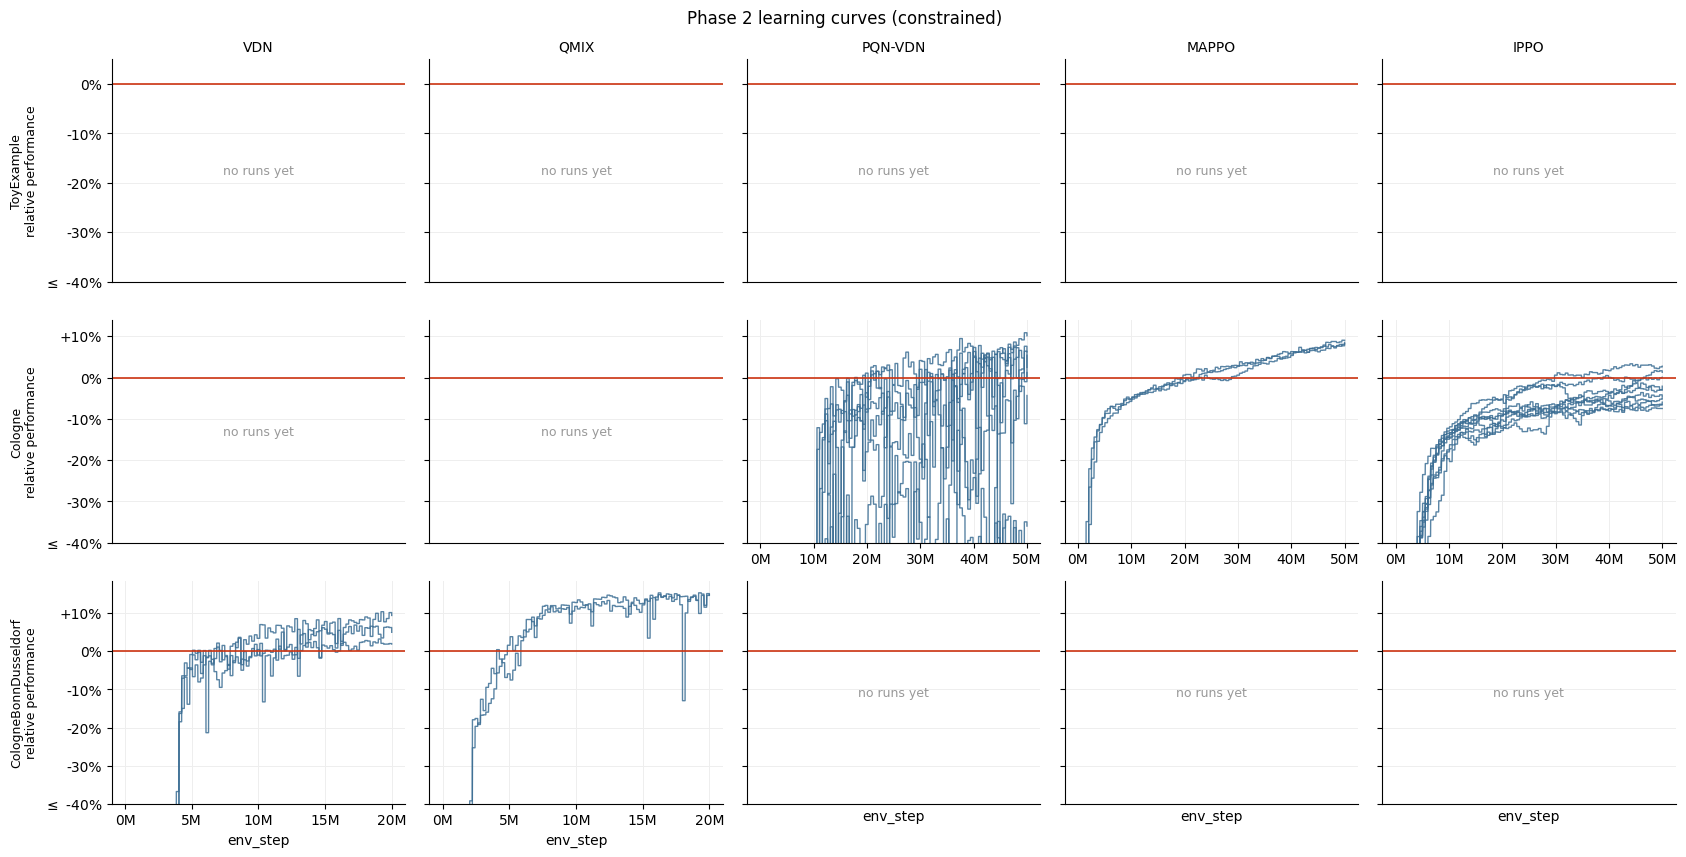

In [44]:
millions_formatter = FuncFormatter(lambda v, _: f"{v / 1e6:,.0f}M")

# The formatter rounds to whole millions, so ticks must land on whole millions
# too — the default locator can place one at 2.5M and label it "2M".
def step_locator():
    return MaxNLocator(nbins=6, steps=[1, 2, 5, 10])


# Curves are built up front so each row's y-limit can be set from its data.
# Autoscaling cannot do it: a row whose first panel has no runs would keep that
# empty panel's default limits for the whole shared row and clip the rest.
curves = {}
for _, run_row in runs_df.iterrows():
    evals = eval_points(loaded_runs.get((run_row["project"], run_row["run_id"])))
    if evals.empty:
        continue
    curves[run_row["run_id"]] = (
        evals["env_step"].to_numpy(),
        relative_to_heuristic(evals[METRIC], run_row["map_name"]).to_numpy(),
    )

row_top = {}
for map_name in MAPS:
    tops = [
        curves[run_id][1].max()
        for run_id in runs_df[runs_df["map_name"] == map_name]["run_id"]
        if run_id in curves
    ]
    row_top[map_name] = max(tops) + 3 if tops else 5

fig, axes = plt.subplots(
    len(MAPS),
    len(ALG_ORDER),
    figsize=(3.4 * len(ALG_ORDER), 2.9 * len(MAPS)),
    sharey="row",
    squeeze=False,
)

for row, (map_name, map_info) in enumerate(MAPS.items()):
    for column, alg in enumerate(ALG_ORDER):
        ax = axes[row][column]
        cell = runs_df[(runs_df["alg"] == alg) & (runs_df["map_name"] == map_name)]

        for run_id in cell["run_id"]:
            if run_id not in curves:
                continue
            env_step, relative = curves[run_id]
            ax.plot(env_step, relative, color=BOX_COLOR, linewidth=1.0, alpha=0.85)

        ax.axhline(0, color=HEURISTIC_COLOR, linewidth=1.2)
        # Early training sits far below the floor; zoom on the plateau.
        ax.set_ylim(Y_FLOOR, row_top[map_name])
        ax.xaxis.set_major_formatter(millions_formatter)
        ax.xaxis.set_major_locator(step_locator())
        ax.yaxis.set_major_formatter(percent_formatter)
        ax.grid(color="#eeeeee", linewidth=0.7)
        ax.set_axisbelow(True)
        for side in ("top", "right"):
            ax.spines[side].set_visible(False)

        if row == 0:
            ax.set_title(ALG_NAMES[alg], fontsize=10)
        if column == 0:
            ax.set_ylabel(
                f"{map_info['title'].splitlines()[0]}\nrelative performance", fontsize=9
            )
        if row == len(MAPS) - 1:
            ax.set_xlabel("env_step")
        if cell.empty:
            # Without data the x-axis would render a row of meaningless "0M".
            ax.set_xticks([])
            ax.annotate(
                "no runs yet",
                xy=(0.5, 0.5),
                xycoords="axes fraction",
                ha="center",
                va="center",
                fontsize=9,
                color="#999999",
            )

fig.suptitle("Phase 2 learning curves (constrained)", fontsize=12)
fig.tight_layout()
plt.show()

## Aggregate curves

One panel per map with every algorithm overlaid: the line is the median across
that algorithm's seeds, the band the interquartile range. This is the same data
as the grid above, collapsed so algorithms can be compared directly within a map.

Seeds are interpolated onto a common `env_step` grid and the aggregate stops at
the shortest seed's last step, so a run still in flight shortens the window
rather than being extrapolated into a flat line. With few seeds the IQR is a
rough spread, not a confidence interval — an algorithm with one seed shows a
median and no band at all.

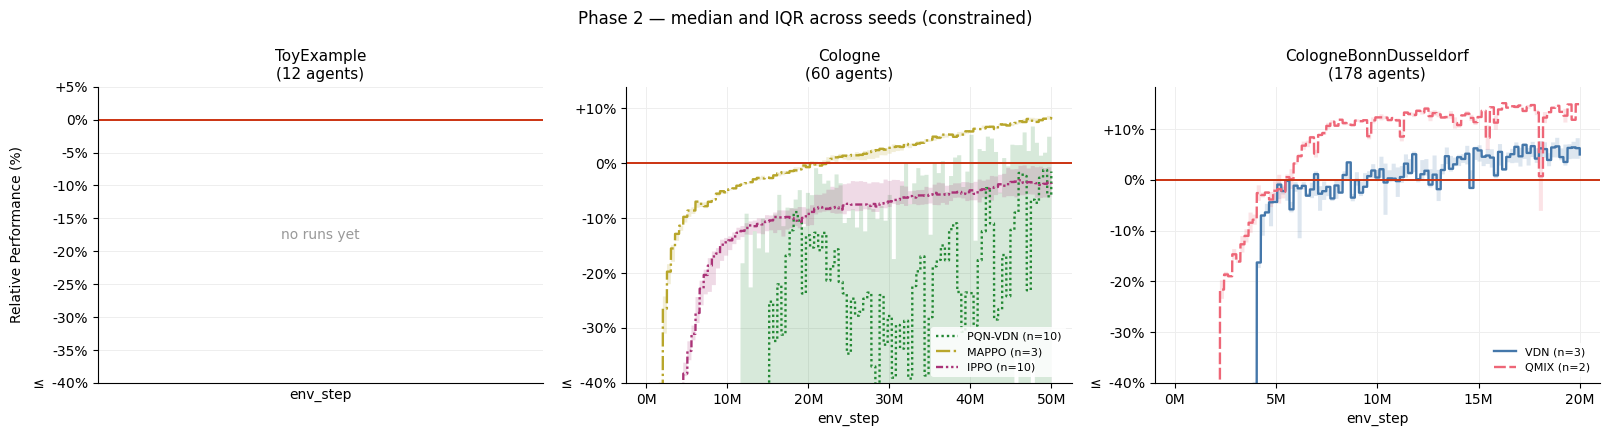

In [45]:
# Fixed algorithm colors, never reassigned, with line style as a second cue so
# identity never rests on color alone. Validated as a categorical set across all
# pairs (worst CVD ΔE 8.3, worst normal-vision ΔE 18.0); the yellow sits under
# 3:1 against white, which the legend and the summary table below cover.
ALG_COLORS = {
    "vdn_rnn": "#4477AA",
    "qmix_rnn": "#EE6677",
    "pqn_rnn": "#228833",
    "mappo_rnn": "#B8A62B",
    "ippo_rnn": "#AA3377",
}
ALG_LINESTYLES = {
    "vdn_rnn": "solid",
    "qmix_rnn": (0, (5, 1.5)),
    "pqn_rnn": (0, (1, 1.3)),
    "mappo_rnn": (0, (6, 1.5, 1, 1.5)),
    "ippo_rnn": (0, (3, 1.2, 1, 1.2, 1, 1.2)),
}


def aggregate_curve(run_ids):
    """Median and IQR across seeds on a common env_step grid.

    Seeds are interpolated onto the densest seed's grid, truncated to the
    shortest seed's last step so an unfinished run is never extrapolated.
    """
    seeds = [curves[run_id] for run_id in run_ids if run_id in curves]
    if not seeds:
        return None

    grid = max(seeds, key=lambda seed: len(seed[0]))[0]
    grid = grid[grid <= min(seed[0].max() for seed in seeds)]
    if not len(grid):
        return None

    stacked = np.vstack(
        [np.interp(grid, env_step, relative) for env_step, relative in seeds]
    )
    return (
        grid,
        np.median(stacked, axis=0),
        np.percentile(stacked, 25, axis=0),
        np.percentile(stacked, 75, axis=0),
    )


fig, axes = plt.subplots(
    1, len(MAPS), figsize=(5.4 * len(MAPS), 4.4), squeeze=False
)

for ax, (map_name, map_info) in zip(axes[0], MAPS.items()):
    plotted = False
    for alg in ALG_ORDER:
        cell = runs_df[(runs_df["alg"] == alg) & (runs_df["map_name"] == map_name)]
        aggregate = aggregate_curve(cell["run_id"])
        if aggregate is None:
            continue
        grid, median, lower, upper = aggregate
        ax.fill_between(
            grid, lower, upper, color=ALG_COLORS[alg], alpha=0.18, linewidth=0
        )
        ax.plot(
            grid,
            median,
            color=ALG_COLORS[alg],
            linestyle=ALG_LINESTYLES[alg],
            linewidth=1.7,
            label=f"{ALG_NAMES[alg]} (n={len(cell)})",
        )
        plotted = True

    ax.axhline(0, color=HEURISTIC_COLOR, linewidth=1.4)
    ax.set_ylim(Y_FLOOR, row_top[map_name])
    ax.xaxis.set_major_formatter(millions_formatter)
    ax.xaxis.set_major_locator(step_locator())
    ax.yaxis.set_major_formatter(percent_formatter)
    ax.grid(color="#eeeeee", linewidth=0.7)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.set_title(map_info["title"], fontsize=11)
    ax.set_xlabel("env_step")

    if plotted:
        ax.legend(
            fontsize=8, loc="lower right", frameon=True,
            framealpha=0.85, edgecolor="none",
        )
    else:
        ax.set_xticks([])
        ax.annotate(
            "no runs yet",
            xy=(0.5, 0.5),
            xycoords="axes fraction",
            ha="center",
            va="center",
            fontsize=10,
            color="#999999",
        )

axes[0][0].set_ylabel("Relative Performance (%)")
fig.suptitle("Phase 2 — median and IQR across seeds (constrained)", fontsize=12)
fig.tight_layout()
plt.show()

## Summary

Median and best seed per algorithm and map, relative to that map's heuristic.
`n` is the number of complete seeds behind each number.

In [46]:
summary_rows = []
for map_name in MAPS:
    for alg in ALG_ORDER:
        values = box_df[
            (box_df["alg"] == alg) & (box_df["map_name"] == map_name)
        ]["best_rel"].dropna()
        summary_rows.append(
            {
                "map": map_name,
                "alg": ALG_NAMES[alg],
                "n": len(values),
                "median_%": values.median(),
                "best_%": values.max(),
                "worst_%": values.min(),
            }
        )

summary_df = pd.DataFrame(summary_rows).set_index(["map", "alg"])
display(
    summary_df.style.format(
        {"median_%": "{:+.2f}%", "best_%": "{:+.2f}%", "worst_%": "{:+.2f}%"},
        na_rep="—",
    )
)